<a href="https://colab.research.google.com/github/parthaborgohain566/Prodigy-Infotech-Internship-Generative-AI-GA/blob/main/Task%2004%3A%20Image-to-Image%20Translation%20with%20cGAN/%20Image_to_Image_Translation_with_cGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image-to-Image Translation with cGAN (Pix2Pix)

This notebook implements a Conditional Generative Adversarial Network (cGAN) for image-to-image translation tasks.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import time

# Define constants
OUTPUT_CHANNELS = 3

def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same', kernel_initializer=initializer, use_bias=False))
    if apply_batchnorm:
        result.add(layers.BatchNormalization())
    result.add(layers.LeakyReLU())
    return result

def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2DTranspose(filters, size, strides=2, padding='same', kernel_initializer=initializer, use_bias=False))
    result.add(layers.BatchNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))
    result.add(layers.ReLU())
    return result

In [ ]:
from tensorflow.keras import layers
import tensorflow as tf

def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same', kernel_initializer=initializer, use_bias=False))
    if apply_batchnorm:
        result.add(layers.BatchNormalization())
    result.add(layers.LeakyReLU())
    return result

def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2DTranspose(filters, size, strides=2, padding='same', kernel_initializer=initializer, use_bias=False))
    result.add(layers.BatchNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))
    result.add(layers.ReLU())
    return result

def Generator():
    inputs = layers.Input(shape=[256, 256, 3])
    down_stack = [
        downsample(64, 4, apply_batchnorm=False),
        downsample(128, 4),
        downsample(256, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
    ]
    up_stack = [
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4),
        upsample(256, 4),
        upsample(128, 4),
        upsample(64, 4),
    ]
    initializer = tf.random_normal_initializer(0., 0.02)
    last = layers.Conv2DTranspose(3, 4, strides=2, padding='same', kernel_initializer=initializer, activation='tanh')

    x = inputs
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)
    skips = reversed(skips[:-1])
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers.Concatenate()([x, skip])
    x = last(x)
    return tf.keras.Model(inputs=inputs, outputs=x)

generator = Generator()

In [ ]:
from tensorflow.keras import layers
import tensorflow as tf

def Discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)
    inp = layers.Input(shape=[256, 256, 3], name='input_image')
    tar = layers.Input(shape=[256, 256, 3], name='target_image')
    x = layers.concatenate([inp, tar])
    down1 = downsample(64, 4, False)(x)
    down2 = downsample(128, 4)(down1)
    down3 = downsample(256, 4)(down2)
    zero_pad1 = layers.ZeroPadding2D()(down3)
    conv = layers.Conv2D(512, 4, strides=1, kernel_initializer=initializer, use_bias=False)(zero_pad1)
    batchnorm1 = layers.BatchNormalization()(conv)
    leaky_relu = layers.LeakyReLU()(batchnorm1)
    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)
    last = layers.Conv2D(1, 4, strides=1, kernel_initializer=initializer)(zero_pad2)
    return tf.keras.Model(inputs=[inp, tar], outputs=last)

discriminator = Discriminator()

## Loss Functions and Optimizers

We define the GAN loss, the L1 loss (to ensure the generated image is close to the target), and the optimizers for both models.

In [ ]:
import tensorflow as tf

loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)
LAMBDA = 100

def generator_loss(disc_generated_output, gen_output, target):
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
    total_gen_loss = gan_loss + (LAMBDA * l1_loss)
    return total_gen_loss, gan_loss, l1_loss

def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)
    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    total_disc_loss = real_loss + generated_loss
    return total_disc_loss

generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

## Training Step and Inference Utility

The `generate_images` function will be used during and after training to visualize the model's output (inference).

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

def generate_images(model, test_input, tar):
    prediction = model(test_input, training=True)
    plt.figure(figsize=(15, 15))
    display_list = [test_input[0], tar[0], prediction[0]]
    title = ['Input Image', 'Ground Truth', 'Predicted Image']
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(title[i])
        plt.imshow(display_list[i] * 0.5 + 0.5)
        plt.axis('off')
    plt.show()

@tf.function
def train_step(input_image, target, step):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(input_image, training=True)
        disc_real_output = discriminator([input_image, target], training=True)
        disc_generated_output = discriminator([input_image, gen_output], training=True)
        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(disc_generated_output, gen_output, target)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

    generator_gradients = gen_tape.gradient(gen_total_loss, generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))

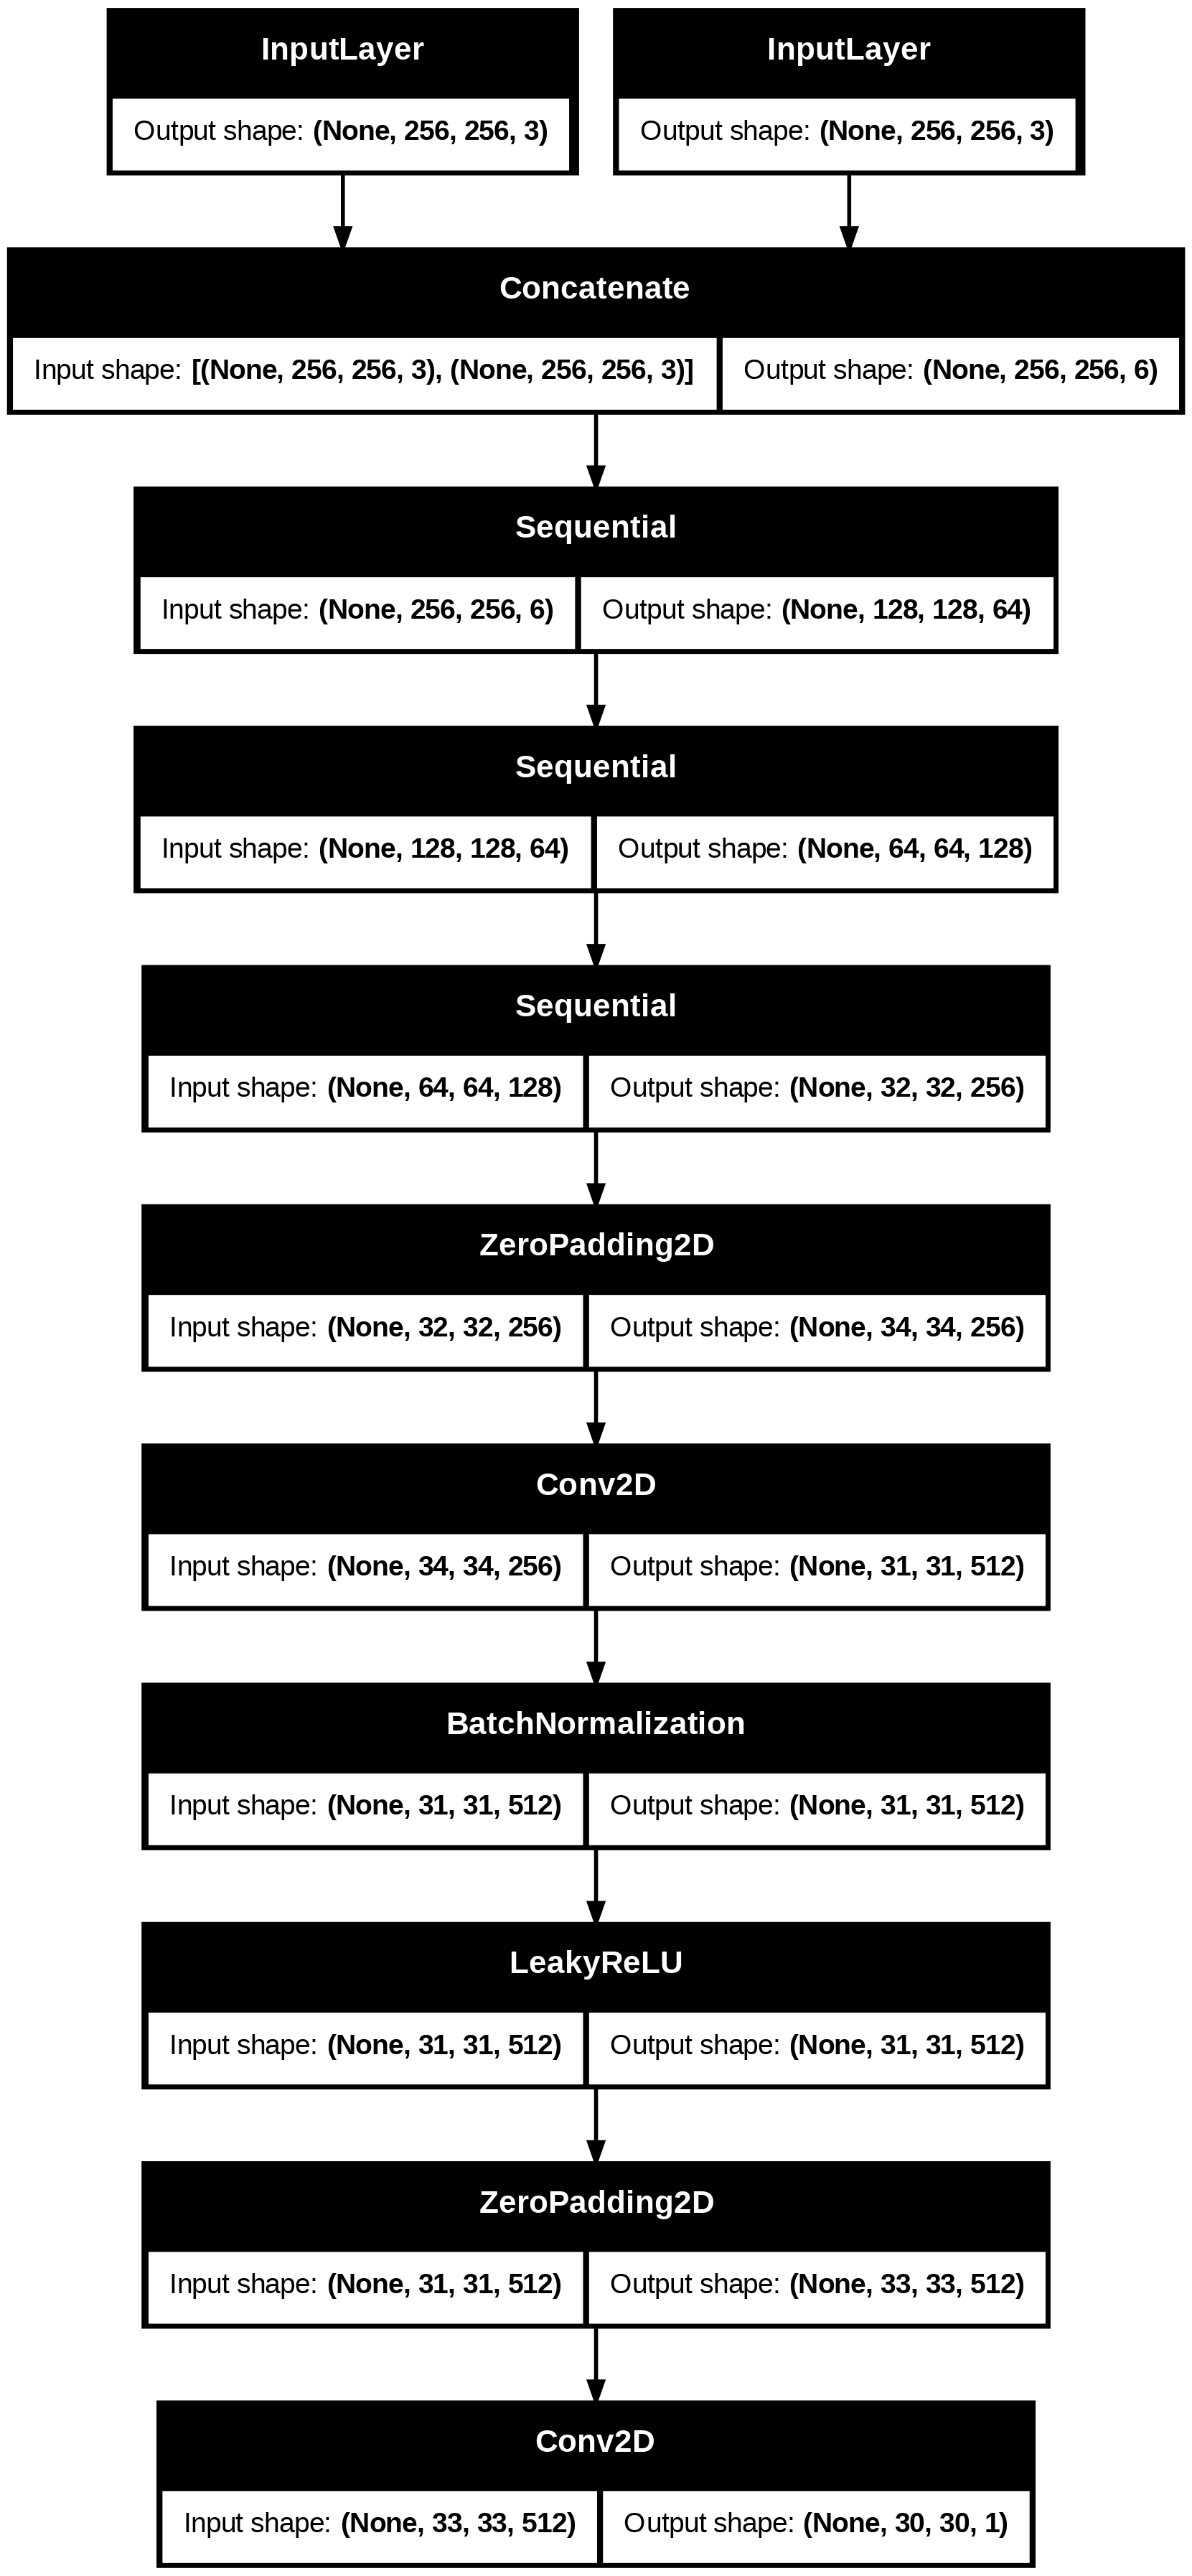

In [ ]:
# Saves visual diagram files locally
tf.keras.utils.plot_model(generator, to_file='generator_model.png', show_shapes=True)
tf.keras.utils.plot_model(discriminator, to_file='discriminator_model.png', show_shapes=True)

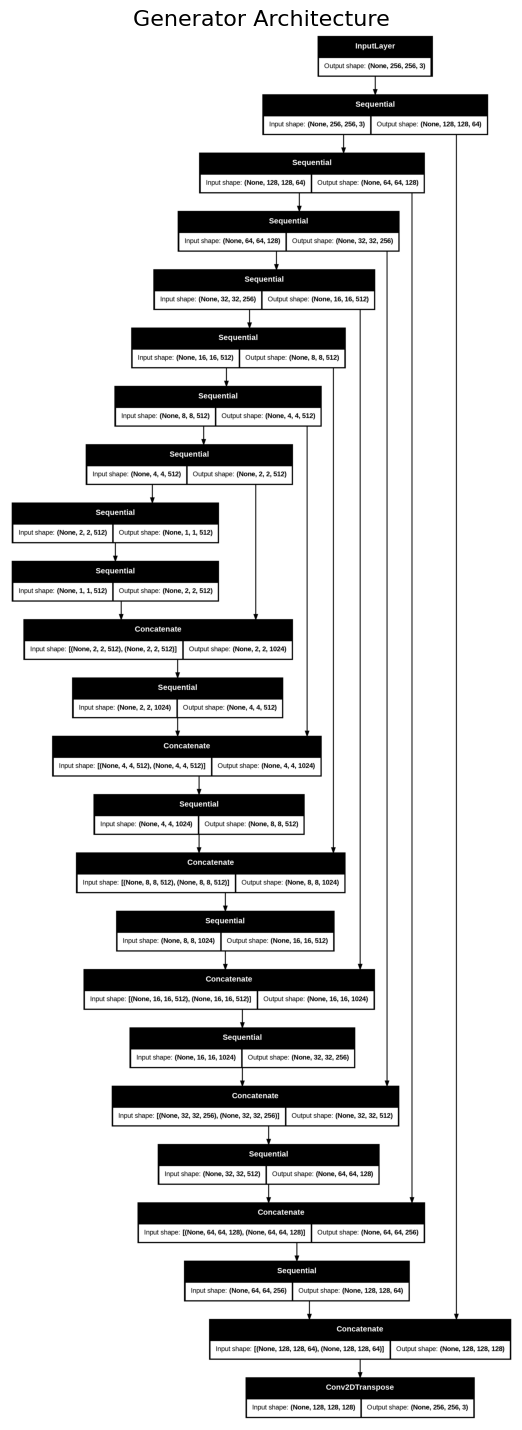

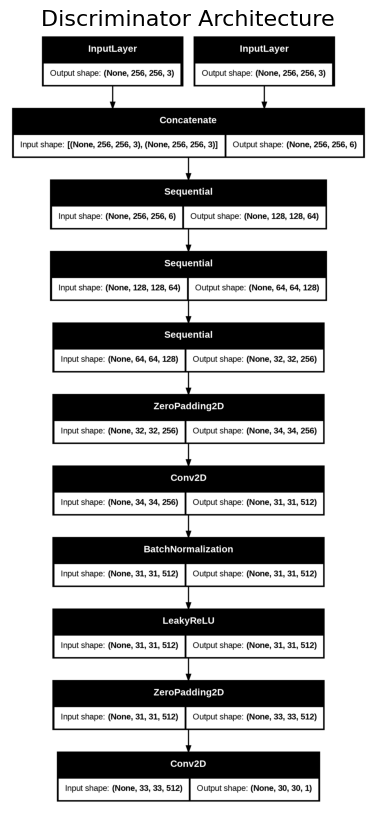

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Plot and display Generator
plt.figure(figsize=(12, 18))
img_gen = mpimg.imread('/content/generator_model.png')
plt.imshow(img_gen)
plt.axis('off')
plt.title("Generator Architecture", fontsize=16)
plt.show()

# Plot and display Discriminator
plt.figure(figsize=(10, 10))
img_disc = mpimg.imread('/content/discriminator_model.png')
plt.imshow(img_disc)
plt.axis('off')
plt.title("Discriminator Architecture", fontsize=16)
plt.show()

## Dataset Loading and Training

We will download the Facades dataset and define the training loop to train the generator and discriminator.

Loading CMP Facades dataset...


Repo card metadata block was not found. Setting CardData to empty.



Epoch 1/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 1 finished in 88.50 sec

Epoch 2/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 2 finished in 75.29 sec

Epoch 3/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 3 finished in 75.78 sec

Epoch 4/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 4 finished in 75.29 sec

Epoch 5/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 5 finished in 81.95 sec


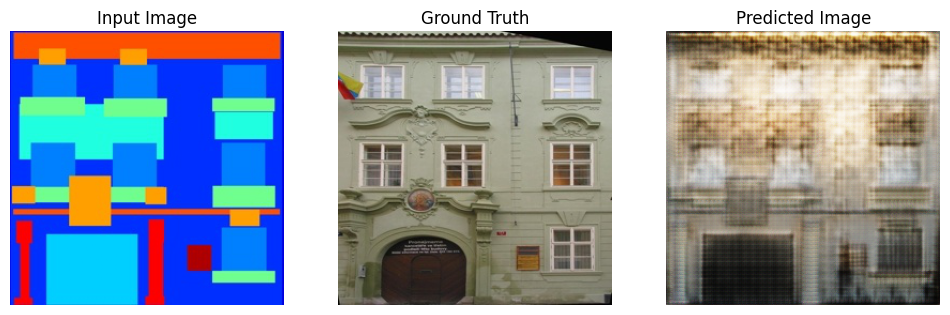


Epoch 6/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 6 finished in 75.66 sec

Epoch 7/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 7 finished in 75.55 sec

Epoch 8/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 8 finished in 77.49 sec

Epoch 9/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 9 finished in 75.62 sec

Epoch 10/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 10 finished in 75.30 sec


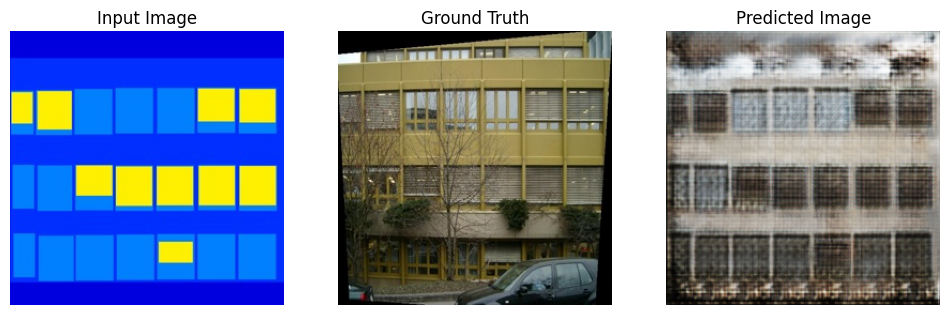


Epoch 11/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 11 finished in 76.55 sec

Epoch 12/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 12 finished in 76.25 sec

Epoch 13/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 13 finished in 76.00 sec

Epoch 14/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 14 finished in 75.67 sec

Epoch 15/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 15 finished in 75.80 sec


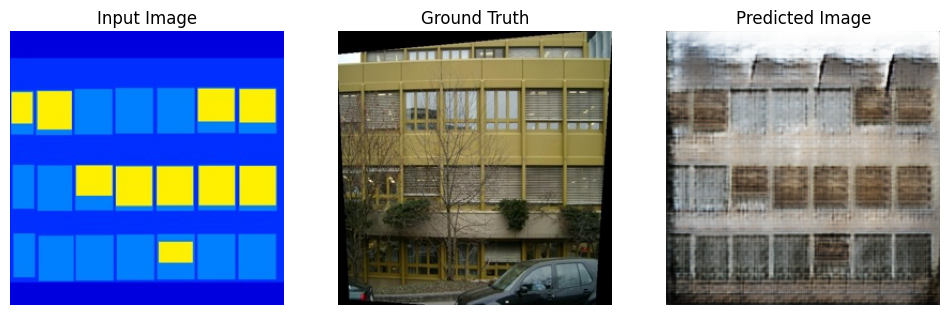


Epoch 16/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 16 finished in 75.27 sec

Epoch 17/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 17 finished in 75.16 sec

Epoch 18/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 18 finished in 75.12 sec

Epoch 19/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 19 finished in 75.12 sec

Epoch 20/20
  Step 100 trained...
  Step 200 trained...
  Step 300 trained...
  Step 400 trained...
  Step 500 trained...
  Step 600 trained...
Epoch 20 finished in 75.05 sec


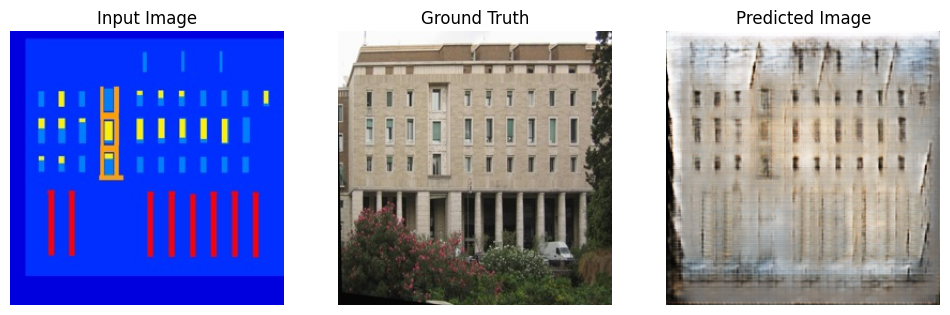

In [ ]:
import io
import time
import numpy as np
import tensorflow as tf
from PIL import Image
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# 1. Load Dataset from Hugging Face
# -------------------------------------------------------------------
try:
    from datasets import load_dataset
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "datasets"])
    from datasets import load_dataset

print("Loading CMP Facades dataset...")
hf_dataset = load_dataset("huggan/facades", split="train")

def parse_hf_image(img_data):
    if isinstance(img_data, dict):
        if 'bytes' in img_data and img_data['bytes'] is not None:
            return Image.open(io.BytesIO(img_data['bytes'])).convert('RGB')
        elif 'path' in img_data and img_data['path'] is not None:
            return Image.open(img_data['path']).convert('RGB')
    elif hasattr(img_data, 'convert'):
        return img_data.convert('RGB')
    return Image.fromarray(np.uint8(img_data)).convert('RGB')

def hf_generator():
    for example in hf_dataset:
        input_pil = parse_hf_image(example['imageA'])
        real_pil = parse_hf_image(example['imageB'])

        input_img = np.array(input_pil, dtype=np.float32)
        real_img = np.array(real_pil, dtype=np.float32)
        yield input_img, real_img

raw_ds = tf.data.Dataset.from_generator(
    hf_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, None, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, None, 3), dtype=tf.float32)
    )
)

# Preprocessing
@tf.function
def preprocess_train(input_image, real_image):
    input_image = tf.image.resize(input_image, [256, 256], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    real_image = tf.image.resize(real_image, [256, 256], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    # Normalize to [-1, 1]
    input_image = (input_image / 127.5) - 1.0
    real_image = (real_image / 127.5) - 1.0
    return input_image, real_image

train_dataset = raw_ds.map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(400).batch(1)

# -------------------------------------------------------------------
# 2. Architectures (U-Net Generator + PatchGAN Discriminator)
# -------------------------------------------------------------------
def downsample(filters, size, apply_batchnorm=True):
    result = tf.keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same', use_bias=False))
    if apply_batchnorm:
        result.add(layers.BatchNormalization())
    result.add(layers.LeakyReLU())
    return result

def upsample(filters, size, apply_dropout=False):
    result = tf.keras.Sequential()
    result.add(layers.Conv2DTranspose(filters, size, strides=2, padding='same', use_bias=False))
    result.add(layers.BatchNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))
    result.add(layers.ReLU())
    return result

def build_generator():
    inputs = layers.Input(shape=[256, 256, 3])
    down_stack = [
        downsample(64, 4, False),
        downsample(128, 4),
        downsample(256, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
    ]
    up_stack = [
        upsample(512, 4, True),
        upsample(512, 4, True),
        upsample(512, 4, True),
        upsample(512, 4),
        upsample(256, 4),
        upsample(128, 4),
        upsample(64, 4),
    ]
    last = layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='tanh')

    x = inputs
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = reversed(skips[:-1])
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers.Concatenate()([x, skip])

    x = last(x)
    return tf.keras.Model(inputs=inputs, outputs=x)

def build_discriminator():
    inp = layers.Input(shape=[256, 256, 3], name='input_image')
    target = layers.Input(shape=[256, 256, 3], name='target_image')

    x = layers.concatenate([inp, target])
    down1 = downsample(64, 4, False)(x)
    down2 = downsample(128, 4)(down1)
    down3 = downsample(256, 4)(down2)

    zero_pad1 = layers.ZeroPadding2D()(down3)
    conv = layers.Conv2D(512, 4, strides=1, use_bias=False)(zero_pad1)
    batchnorm1 = layers.BatchNormalization()(conv)
    leaky_relu = layers.LeakyReLU()(batchnorm1)

    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)
    last = layers.Conv2D(1, 4, strides=1)(zero_pad2)

    return tf.keras.Model(inputs=[inp, target], outputs=last)

generator = build_generator()
discriminator = build_discriminator()

# -------------------------------------------------------------------
# 3. Losses & Optimizers
# -------------------------------------------------------------------
LAMBDA = 100
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(disc_generated_output, gen_output, target):
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
    total_gen_loss = gan_loss + (LAMBDA * l1_loss)
    return total_gen_loss

def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)
    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    return real_loss + generated_loss

generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

# -------------------------------------------------------------------
# 4. Actual Active Training Step
# -------------------------------------------------------------------
@tf.function
def train_step(input_image, target):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(input_image, training=True)

        disc_real_output = discriminator([input_image, target], training=True)
        disc_generated_output = discriminator([input_image, gen_output], training=True)

        gen_loss = generator_loss(disc_generated_output, gen_output, target)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

    # Compute & Apply Gradients
    generator_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))

def generate_images(model, test_input, target):
    prediction = model(test_input, training=False)
    plt.figure(figsize=(12, 4))

    display_list = [test_input[0], target[0], prediction[0]]
    title = ['Input Image', 'Ground Truth', 'Predicted Image']

    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(title[i])
        # Rescale [-1, 1] -> [0, 1]
        plt.imshow(display_list[i] * 0.5 + 0.5)
        plt.axis('off')
    plt.show()

def fit(train_ds, epochs):
    for epoch in range(epochs):
        start = time.time()
        print(f"\nEpoch {epoch+1}/{epochs}")

        for n, (input_image, target) in train_ds.enumerate():
            train_step(input_image, target)
            if (n + 1) % 100 == 0:
                print(f"  Step {n+1} trained...")

        print(f"Epoch {epoch+1} finished in {time.time()-start:.2f} sec")

        # Display progress sample every 5 epochs
        if (epoch + 1) % 5 == 0:
            for example_input, example_target in train_ds.take(1):
                generate_images(generator, example_input, example_target)

# Train for 20 epochs to get visible results
fit(train_dataset, epochs=20)

In [ ]:
# Save weights locally
generator.save_weights('generator_facades.weights.h5')
discriminator.save_weights('discriminator_facades.weights.h5')

# Or save the full generator model
generator.save('pix2pix_generator.keras')
print("Model successfully saved!")

Model successfully saved!


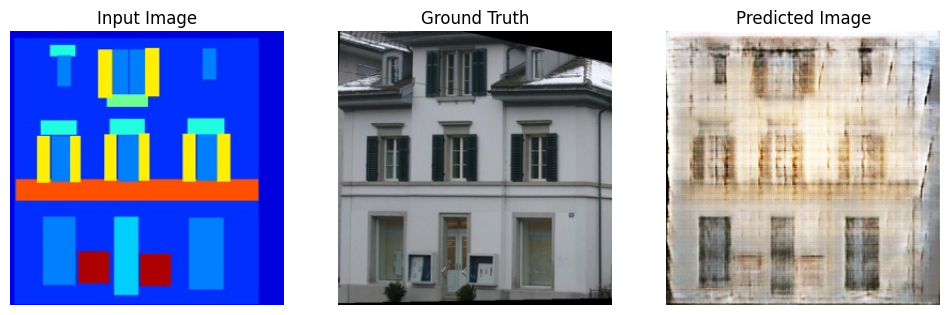

In [ ]:
import matplotlib.pyplot as plt

def display_predictions(model, test_input, target):
    # Generate prediction from model
    prediction = model(test_input, training=False)

    plt.figure(figsize=(12, 4))
    display_list = [test_input[0], target[0], prediction[0]]
    title = ['Input Image', 'Ground Truth', 'Predicted Image']

    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.title(title[i])
        # Rescale pixel values from [-1, 1] to [0, 1] for display
        plt.imshow(display_list[i] * 0.5 + 0.5)
        plt.axis('off')
    plt.show()

# Get one batch from your training dataset
for example_input, example_target in train_dataset.take(1):
    display_predictions(generator, example_input, example_target)